In [1]:
from configs import *
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from scipy.linalg import solve_discrete_are
import imageio


In [ ]:
env.reset(seed=42)
model = env.unwrapped.model
print(model.nv)
print(model.nq)
print(model.nu)


2
2
1


In [5]:
import gymnasium as gym
import mujoco
import numpy as np

# Create environment
env = gym.make("InvertedPendulum-v5", render_mode="rgb_array", reset_noise_scale=0.0001) 
env.reset()

# Access the MuJoCo model and data
model = env.unwrapped.model
data = env.unwrapped.data

# Set integrator to Euler (necessary for mjd_transitionFD)
model.opt.integrator = mujoco.mjtIntegrator.mjINT_EULER

# Dimensions
nv = model.nv         # number of generalized velocities
nu = model.nu         # number of controls
nstate = 2 * nv       # state = [qpos, qvel]

# Set a known state and control
qpos0 = np.copy(data.qpos)
qvel0 = np.copy(data.qvel)
ctrl0 = np.zeros(nu)

# Reset and set the desired state
mujoco.mj_resetData(model, data)
data.qpos[:] = qpos0
data.qvel[:] = qvel0
data.ctrl[:] = ctrl0

# Allocate A and B
A = np.zeros((nstate, nstate))
B = np.zeros((nstate, nu))

# Finite difference settings
epsilon = 1e-6
centered = True

# Compute A and B
mujoco.mjd_transitionFD(model, data, epsilon, centered, A, B, None, None)

# Print the qpos0, qvel0, and ctrl0
print("qpos0:", qpos0)
print("qvel0:", qvel0)
print("ctrl0:", ctrl0)

# Print the linearized system matrices
print("A matrix:")
print(A)

print("\nB matrix:")
print(B)


qpos0: [ 3.89933045e-05 -8.79589155e-05]
qvel0: [5.79680800e-05 8.51043832e-05]
ctrl0: [0.]
A matrix:
[[ 1.00000000e+00 -1.11507854e-03  1.99668827e-02  7.54979301e-05]
 [ 0.00000000e+00  1.01148765e+00  7.54979167e-05  1.92222151e-02]
 [ 0.00000000e+00 -5.57539271e-02  9.98344135e-01  3.77489650e-03]
 [ 0.00000000e+00  5.74382295e-01  3.77489583e-03  9.61110757e-01]]

B matrix:
[[ 0.00331173]
 [-0.00754979]
 [ 0.16558646]
 [-0.37748958]]


In [12]:
import gymnasium as gym
import mujoco
import numpy as np
import copy

# Initialize environment
env = gym.make("InvertedPendulum-v5", render_mode="rgb_array", reset_noise_scale=0.0001)
env.reset(seed=42)

model = env.unwrapped.model
data = env.unwrapped.data

# Parameters
nq = model.nq  # 2 (positions)
nv = model.nv  # 2 (velocities)
nu = model.nu  # 1 (actuator inputs)
nx = nq + nv   # full state size (4)
eps = 1e-6     # finite difference step

# Get initial state
x0 = np.concatenate([data.qpos.copy(), data.qvel.copy()])

# Compute nominal acceleration
mujoco.mj_forward(model, data)
qacc0 = data.qacc.copy()

# Create A and B matrices
A = np.zeros((nx, nx))
B = np.zeros((nx, nu))

# Create a scratch copy of data
data_scratch = mujoco.MjData(model)

# ----- Compute A: df/dx -----
for i in range(nx):
    # Perturb state
    dx = np.zeros(nx)
    dx[i] = eps
    
    # Split into qpos and qvel
    dqpos = dx[:nq]
    dqvel = dx[nq:]
    
    # Copy state and apply perturbation
    data_perturbed = mujoco.MjData(model)
    data_perturbed.qpos[:] = data.qpos + dqpos
    data_perturbed.qvel[:] = data.qvel + dqvel
    mujoco.mj_forward(model, data_perturbed)
    
    # Finite difference on qvel and qacc (since MuJoCo is second-order)
    A[:, i] = np.concatenate([
        (data_perturbed.qvel - data.qvel) / eps,
        (data_perturbed.qacc - qacc0) / eps
    ])

# ----- Compute B: df/du -----
for i in range(nu):
    du = np.zeros(nu)
    du[i] = eps

    # Copy state
    data_perturbed = mujoco.MjData(model)
    data_perturbed.qpos[:] = data.qpos
    data_perturbed.qvel[:] = data.qvel
    data_perturbed.ctrl[:] = data.ctrl + du
    mujoco.mj_forward(model, data_perturbed)

    # Finite difference on qacc
    B[:, i] = np.concatenate([
        np.zeros(nq),  # qvel is not directly affected by control
        (data_perturbed.qacc - qacc0) / eps
    ])

# Print results
np.set_printoptions(precision=5, suppress=True)
print("A matrix:\n", A)
print("B matrix:\n", B)


A matrix:
 [[ 0.       0.       1.       0.     ]
 [ 0.       0.       0.       1.     ]
 [ 0.      -2.90535 -0.08367  0.19671]
 [ 0.      29.89257  0.19671 -2.02391]]
B matrix:
 [[  0.     ]
 [  0.     ]
 [  8.36743]
 [-19.67105]]


In [13]:
# Assuming A is already defined
U, S, VT = np.linalg.svd(A)

print("Singular values:\n", S)

Singular values:
 [30.10295  1.00205  0.9977   0.     ]


In [14]:
import numpy as np

# Do full SVD
U, S, VT = np.linalg.svd(A)

# Choose rank k (e.g., k = 2)
k = 2
U_k = U[:, :k]
S_k = np.diag(S[:k])
VT_k = VT[:k, :]

# Reconstruct low-rank approximation of A
A_k = U_k @ S_k @ VT_k

print("Original A:\n", A)
print("Reduced-rank A_k:\n", A_k)


Original A:
 [[ 0.       0.       1.       0.     ]
 [ 0.       0.       0.       1.     ]
 [ 0.      -2.90535 -0.08367  0.19671]
 [ 0.      29.89257  0.19671 -2.02391]]
Reduced-rank A_k:
 [[ 0.       0.00357  0.99723  0.05241]
 [ 0.      -0.06764  0.05241  0.00738]
 [ 0.      -2.90556 -0.08351  0.19358]
 [ 0.      29.8924   0.19685 -2.02647]]


In [22]:
# get the model time step
model.opt.timestep

0.02

In [18]:
import gymnasium as gym
import numpy as np
from gymnasium.wrappers import RecordVideo
from scipy.linalg import solve_continuous_are
import os

# --- A and B matrices from linearized dynamics ---
A_full = np.array([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [0, -2.90535, -0.08367, 0.19671],
    [0, 29.89257, 0.19671, -2.02391]
])
B = np.array([
    [0],
    [0],
    [8.36743],
    [-19.67105]
])

# --- Truncated SVD for reduced A ---
def reduce_rank(A, k):
    U, S, VT = np.linalg.svd(A)
    return U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]

# --- LQR gain computation ---
def lqr_gain(A, B, Q, R):
    P = solve_continuous_are(A, B, Q, R)
    return np.linalg.inv(R) @ B.T @ P

# --- Simulate one episode and record video ---
def simulate(env_name, A, B, noise_std, video_prefix):
    env = gym.make(env_name, render_mode="rgb_array", reset_noise_scale=0.0001)
    video_dir = "lqr_videos"
    os.makedirs(video_dir, exist_ok=True)
    env = RecordVideo(env, video_folder=video_dir, name_prefix=video_prefix, episode_trigger=lambda x: True)

    observation, _ = env.reset(seed=42)

    # LQR design
    Q = np.diag([10, 100, 1, 1])
    R = np.array([[1]])
    K = lqr_gain(A, B, Q, R)

    total_reward = 0
    for _ in range(500):
        x = np.array(observation[:4])
        x_noisy = x + np.random.normal(0, noise_std, size=x.shape)
        u = -K @ x_noisy
        observation, reward, terminated, truncated, _ = env.step(u)
        total_reward += reward
        if terminated or truncated:
            break

    env.close()
    print(f"[{video_prefix}] Total reward: {total_reward:.2f}")

# --- Run both simulations ---
simulate(
    env_name="InvertedPendulum-v5",
    A=A_full,
    B=B,
    noise_std=0.001,
    video_prefix="lqr_full_rank"
)

simulate(
    env_name="InvertedPendulum-v5",
    A=reduce_rank(A_full, k=2),
    B=B,
    noise_std=0.001,
    video_prefix="lqr_reduced_rank"
)


[lqr_full_rank] Total reward: 500.00
[lqr_reduced_rank] Total reward: 22.00


Episode terminated at step 30


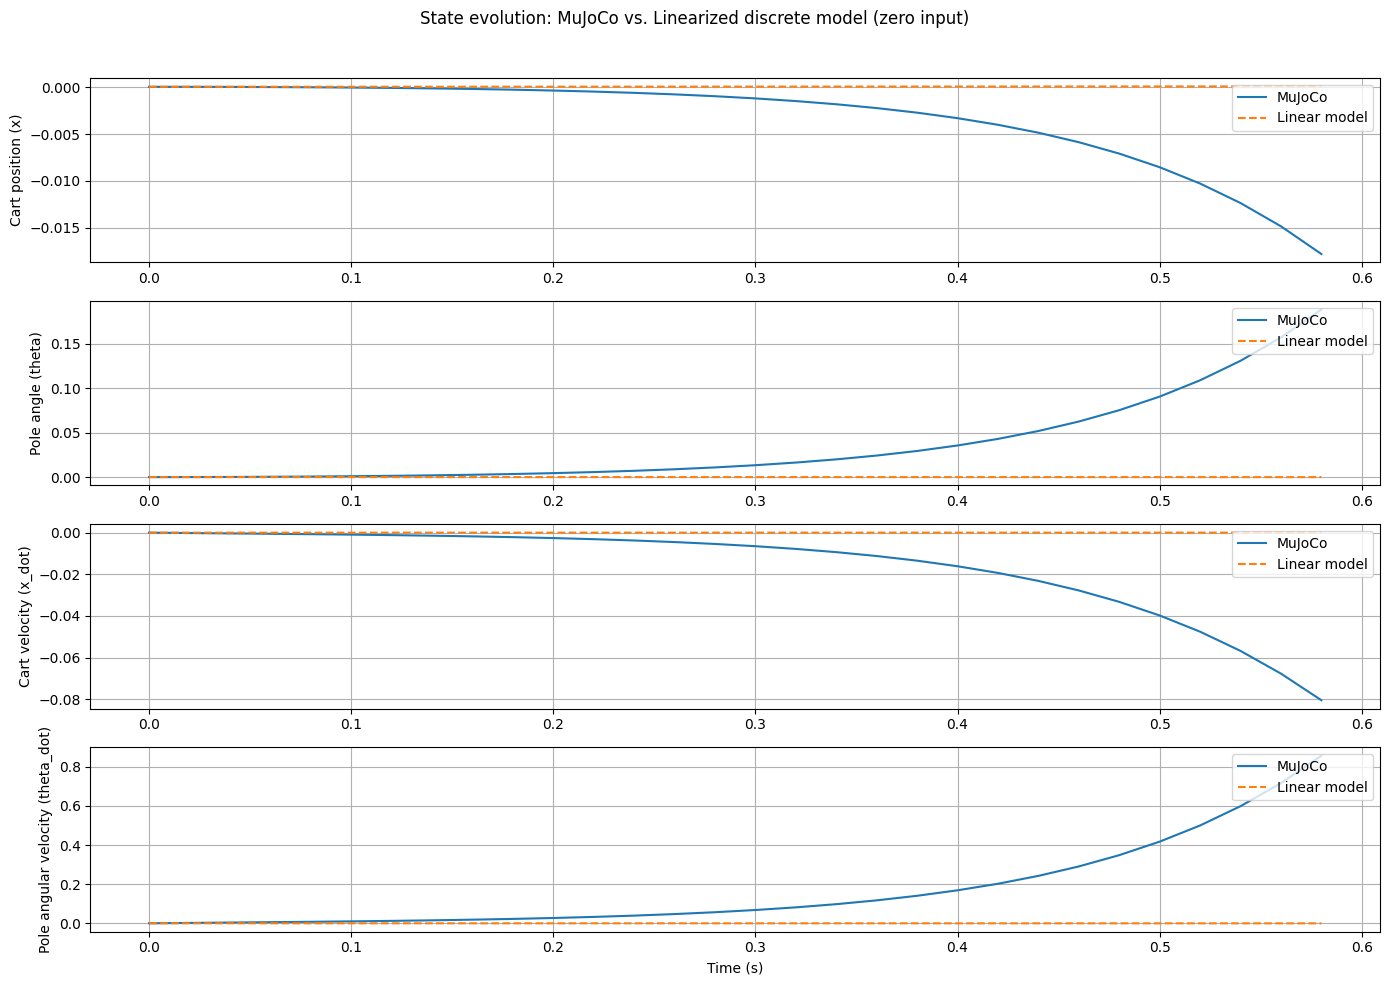

In [21]:
import numpy as np
import gymnasium as gym
from scipy.linalg import expm
import matplotlib.pyplot as plt

# Continuous-time A and B matrices (given)
A_c = np.array([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [0, -2.90535, -0.08367, 0.19671],
    [0, 29.89257, 0.19671, -2.02391]
])
B_c = np.array([
    [0],
    [0],
    [8.36743],
    [-19.67105]
])

dt = 0.02  # MuJoCo timestep

def discretize(A_c, B_c, dt):
    n = A_c.shape[0]
    m = B_c.shape[1]
    M = np.zeros((n+m, n+m))
    M[:n, :n] = A_c * dt
    M[:n, n:] = B_c * dt
    expM = expm(M)
    A_d = expM[:n, :n]
    B_d = expM[:n, n:]
    return A_d, B_d

A_d, B_d = discretize(A_c, B_c, dt)

# Setup environment
env = gym.make("InvertedPendulum-v5", render_mode="rgb_array", reset_noise_scale=0.0001)
obs, info = env.reset(seed=42)

# Initial state vector (copy to avoid modifying env's internal state)
x_k = obs.copy()

# Simulation parameters
n_steps = 100
u_k = np.array([0.0])  # zero input

# Store trajectories for plotting
states_mujoco = []
states_linear = []

# Initialize linear model state
x_lin = x_k.copy()

for t in range(n_steps):
    # Record current states
    states_mujoco.append(obs.copy())
    states_linear.append(x_lin.copy())
    
    # Step linear model
    x_lin = A_d @ x_lin + B_d @ u_k
    
    # Step MuJoCo env with same input
    obs, reward, done, truncated, info = env.step(u_k)
    if done or truncated:
        print(f"Episode terminated at step {t+1}")
        break

# Convert lists to arrays for easier slicing
states_mujoco = np.array(states_mujoco)
states_linear = np.array(states_linear)

# Plotting states over time
time = np.arange(states_mujoco.shape[0]) * dt

state_labels = ["Cart position (x)", "Pole angle (theta)", "Cart velocity (x_dot)", "Pole angular velocity (theta_dot)"]

plt.figure(figsize=(14, 10))
for i in range(4):
    plt.subplot(4,1,i+1)
    plt.plot(time, states_mujoco[:, i], label="MuJoCo")
    plt.plot(time, states_linear[:, i], label="Linear model", linestyle='--')
    plt.ylabel(state_labels[i])
    plt.legend(loc="upper right")
    plt.grid(True)

plt.xlabel("Time (s)")
plt.suptitle("State evolution: MuJoCo vs. Linearized discrete model (zero input)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


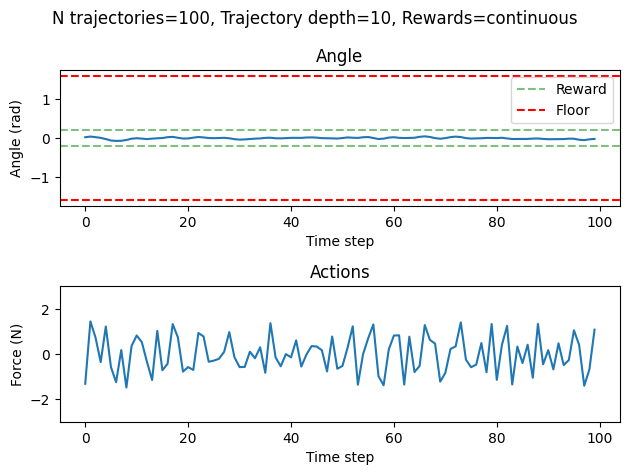

In [5]:
def simulate(bird, n_episodes, time_steps):
    """ Simulate bird, possible episodic SARSA. """

    # Initialize trajectory tracking [episode, time_step, SAR]
    hist = np.zeros((n_episodes, time_steps, 3), dtype=int)

    # Episodic loop
    for epi in range(n_episodes):
        episode_seed = 54 + epi
        np.random.seed(episode_seed)
        # Create the environment
        env = gym.make("InvertedPendulum-v5", render_mode="rgb_array", reset_noise_scale=0.0001) 
        env.reset(seed=episode_seed)
        writer = imageio.get_writer("output.gif", fps=30)

        angles   = np.zeros((time_steps))
        actions  = np.zeros((time_steps))
        rewards  = np.zeros((time_steps))

        for t in range(time_steps):
            #print(f"States: {env.unwrapped.data.qpos}, {env.unwrapped.data.qvel}")
            action = bird.mujoco_policy(env)
            actions[t] = action

            obs, reward, done, truncated, info = env.step(np.array([action]))

            angles[t] = obs[1]
            rewards[t] = reward

            if epi == n_episodes - 1:
                frame = env.render()  # Returns a NumPy RGB array (H, W, 3)
                frame = np.asarray(frame).astype(np.uint8)
                writer.append_data(frame)

            # Learning
            # if train: bird.update(state, action, reward, next_state, next_action)

        # Release the VideoWriter object and close the environment
        writer.close()
        env.close()

    return angles, actions, rewards


# Simulate the bird
planning_width = 100 # how many trajectories to simulate
n_planning = 10 # how deep the rolout of each trajectory is
reward_type='continuous' # rewards can be 'discrete' or 'continuous'

bird = MPCShittyBird(n_actions = 10, planning_width=planning_width, n_planning=n_planning, reward_type=reward_type) 

angle, actions, rewards = simulate(bird, n_episodes=1, time_steps=100)

plt.figure()
plt.suptitle(f'N trajectories={planning_width}, Trajectory depth={n_planning}, Rewards={reward_type}', fontsize=12)

# Plot the angle
plt.subplot(2, 1, 1)
plt.plot(angle)
plt.title('Angle')
plt.xlabel('Time step')
plt.ylabel('Angle (rad)')
plt.axhline(y=-0.2, color='g', linestyle='--', alpha=0.5, label='Reward')
plt.axhline(y=0.2, color='g', linestyle='--', alpha=0.5)
plt.axhline(y=-1.573, color='r', linestyle='--', label='Floor')
plt.axhline(y=1.573, color='r', linestyle='--')
plt.legend()

# Plot the actions
plt.subplot(2, 1, 2)
plt.plot(actions)
plt.title('Actions')
plt.xlabel('Time step')
plt.ylabel('Force (N)')
plt.ylim(-3, 3)

plt.tight_layout()
